##### Inital settings and import dependecies

In [1]:
import sys
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import pytorch_lightning as pl
import numpy as np

from explainability_utils import *

# Add the 'training' directory to sys.path
sys.path.append(os.path.abspath("../training"))
from training_utils import CNN2D, SpectraDataset_s, SpectraDataset_p

c:\Users\frmar\OneDrive\Desktop\GitHub\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42
Seed set to 42


(../preprocessed_dset/sp_64\train) Mean: [0.67176665 0.65817659 0.6412554 ], Std: [0.1186761  0.12021562 0.11939131] (calculated and saved)
(../preprocessed_dset/sp_32\train) Mean: [0.65032865 0.63513704 0.61763785], Std: [0.12265336 0.12450042 0.12385332] (calculated and saved)


In [2]:
# Path to the data
data_path_64 = "../preprocessed_dset/sp_64"
data_path_32 = "../preprocessed_dset/sp_32"
meta_path = "../preprocessed_dset/features_and_metadata.csv"

data_path_64_p = os.path.join(data_path_64, "explainer_p_wave")
data_path_32_p = os.path.join(data_path_32, "explainer_p_wave")
data_path_64_s = os.path.join(data_path_64, "explainer_s_wave")
data_path_32_s = os.path.join(data_path_32, "explainer_s_wave")

f_t_range_64_path = os.path.join(data_path_64, "f_t_range.npy")
f_t_range_32_path = os.path.join(data_path_32, "f_t_range.npy")
tf64, tf32 = np.load(f_t_range_64_path), np.load(f_t_range_32_path)

ft = [tf64[:2], tf64[2:], tf32[:2], tf32[2:]]

# Path to the best model found in the training notebooks
best_model_p_64 = "../training/p_wave_model_checkpoints/model_checkpoints_64/best_model_fold_s.ckpt"
best_model_p_32 = "../training/p_wave_model_checkpoints/model_checkpoints_32/best_model_fold.ckpt"

dim_p64 = (33, 188)
dim_p32 = (17, 155)

# Setting for the datasets
mean_64, std_64 = spectra_stats(os.path.join(data_path_64, "train"))
mean_32, std_32 = spectra_stats(os.path.join(data_path_32, "train"))

transform_64 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_64, std=std_64)
])

transform_32 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_32, std=std_32)
])

(../preprocessed_dset/sp_64\train) Mean: [0.67176665 0.65817659 0.6412554 ], Std: [0.1186761  0.12021562 0.11939131] (calculated and saved)
(../preprocessed_dset/sp_32\train) Mean: [0.65032865 0.63513704 0.61763785], Std: [0.12265336 0.12450042 0.12385332] (calculated and saved)


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
model = CNN2D.load_from_checkpoint(best_model_p_64, input_dim=dim_p64, num_classes=2)
model.eval()
model.to(device)
print("Model loaded")

Model loaded


#### Foreshocks

In [5]:
dset_pre = SpectraDataset_p(os.path.join(data_path_64_p, "foreshock"), transform=transform_64, get_image_name=True)
dloader_pre = DataLoader(dset_pre, batch_size=30, shuffle=False)

PartitionExplainer explainer: 2it [00:27, 27.49s/it]               
PartitionExplainer explainer: 2it [00:28, 28.46s/it]               
PartitionExplainer explainer: 2it [00:18, 18.39s/it]               


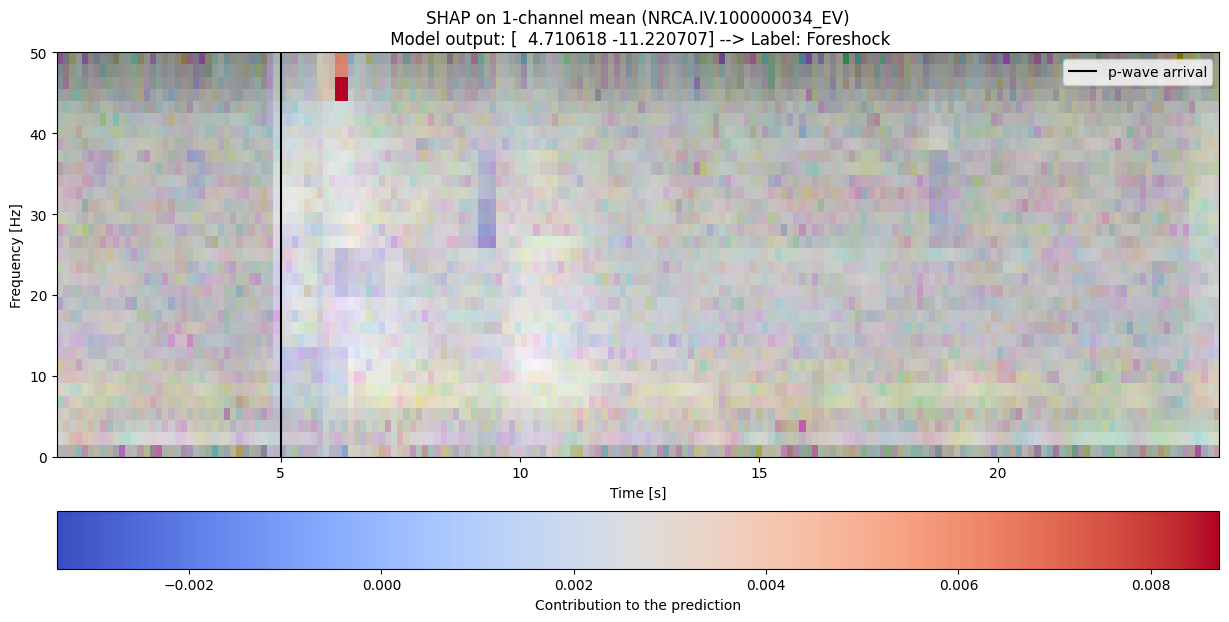

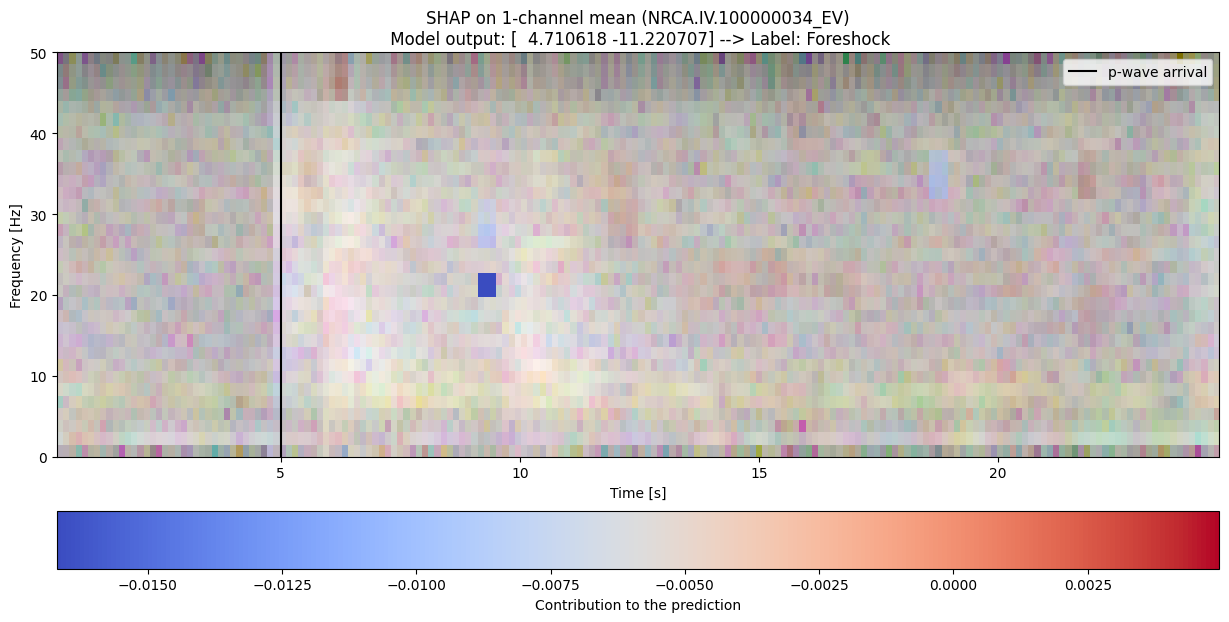

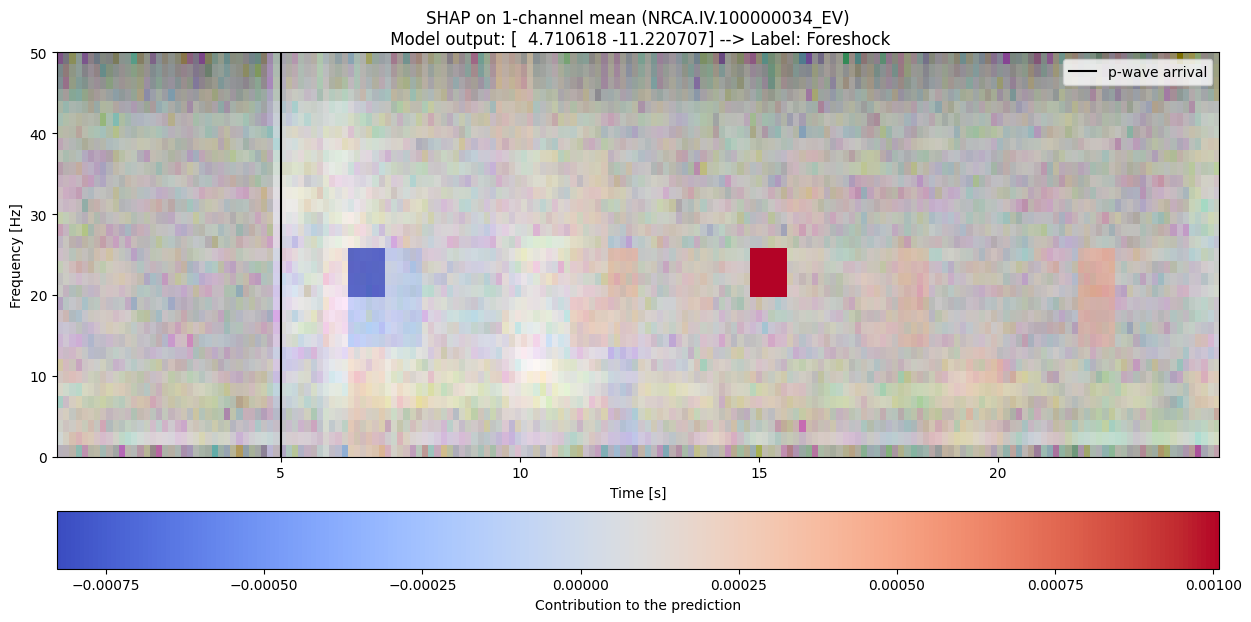

In [6]:
# SHAP Example on 1 sample
example_dataloader = DataLoader(dset_pre, batch_size=1, shuffle=False)
example_iter = next(iter(example_dataloader))

example_images, labels, names = example_iter
model_outputs = model(example_images.to(device))

example_p64_pre_1 = compute_shap_tensor(model, example_iter, dim_p64, device, max_evals=5000)
example_p64_pre_2 = compute_shap_tensor(model, example_iter, dim_p64, device, max_evals=5000, masker_settings="inpaint_ns")
example_p64_pre_3 = compute_shap_tensor(model, example_iter, dim_p64, device, max_evals=5000, masker_settings="blur(3, 3)")

plot_shap(example_p64_pre_1[0], onechannel=True, background=example_images[0], ft=ft, label=labels[0], name=names[0], model_output=model_outputs[0], spec_type="p64", figsize=(15, 7))
plot_shap(example_p64_pre_2[0], onechannel=True, background=example_images[0], ft=ft, label=labels[0], name=names[0], model_output=model_outputs[0], spec_type="p64", figsize=(15, 7))
plot_shap(example_p64_pre_3[0], onechannel=True, background=example_images[0], ft=ft, label=labels[0], name=names[0], model_output=model_outputs[0], spec_type="p64", figsize=(15, 7))

In [8]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_pre, dim_p64, device, max_evals = 10, masker_settings = "inpaint_telea", save_path = None)

Computing Mean SHAP Tensor: 100%|██████████| 11/11 [00:26<00:00,  2.39s/it]


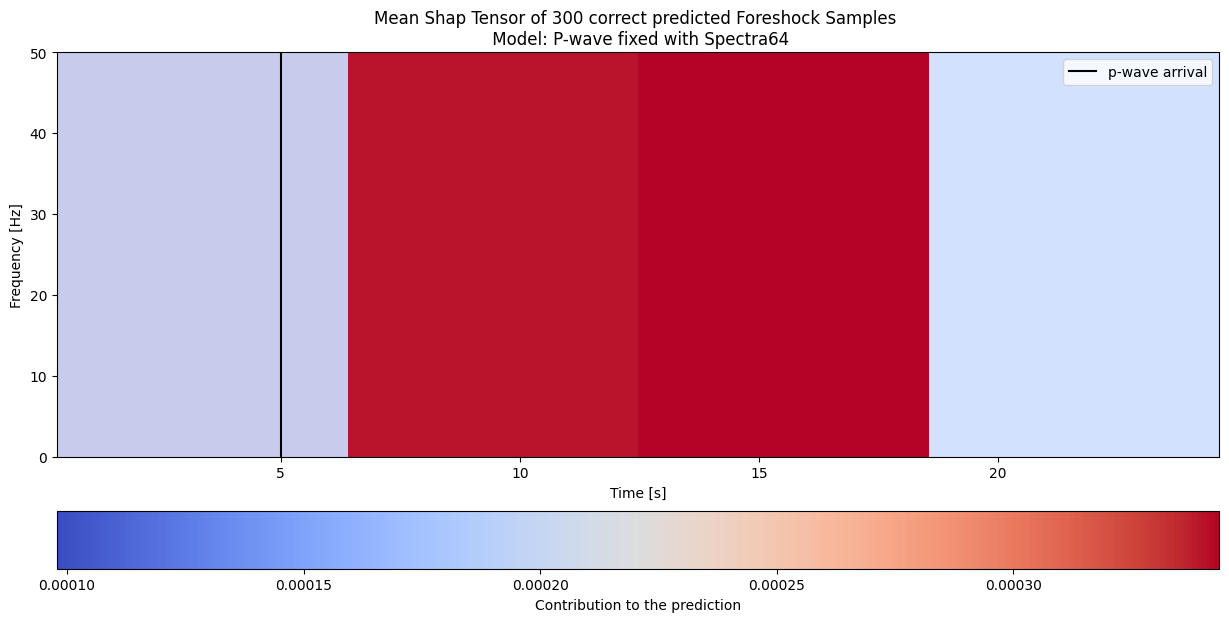

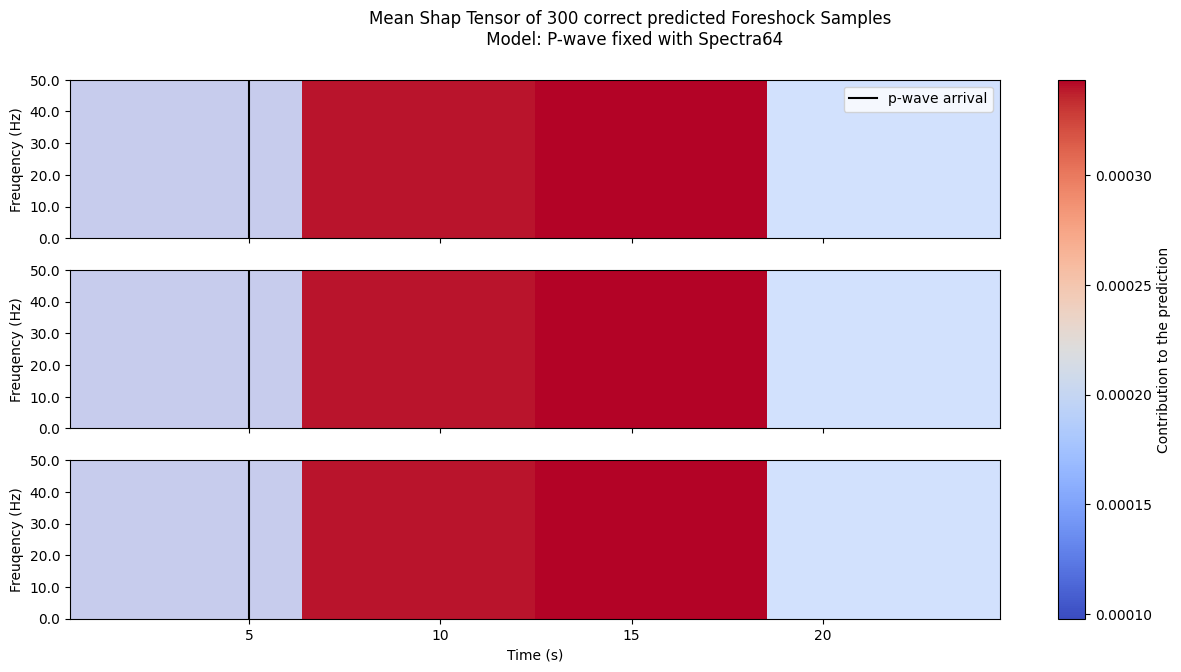

In [10]:
plot_shap(mean_shap_tensor, onechannel=True, background=None, ft = ft, spec_type="p64", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: P-wave fixed with Spectra64")
plot_shap(mean_shap_tensor, onechannel=False, background=None, ft = ft, spec_type="p64", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: P-wave fixed with Spectra64")

#### Aftershock

In [11]:
dset_post = SpectraDataset_p(os.path.join(data_path_64_p, "aftershock"), transform=transform_64, get_image_name=True)
dloader_post = DataLoader(dset_post, batch_size=30, shuffle=False)

In [13]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_post, dim_p64, device, max_evals = 10, masker_settings = "inpaint_telea", save_path = None)

Computing Mean SHAP Tensor: 100%|██████████| 14/14 [00:31<00:00,  2.23s/it]


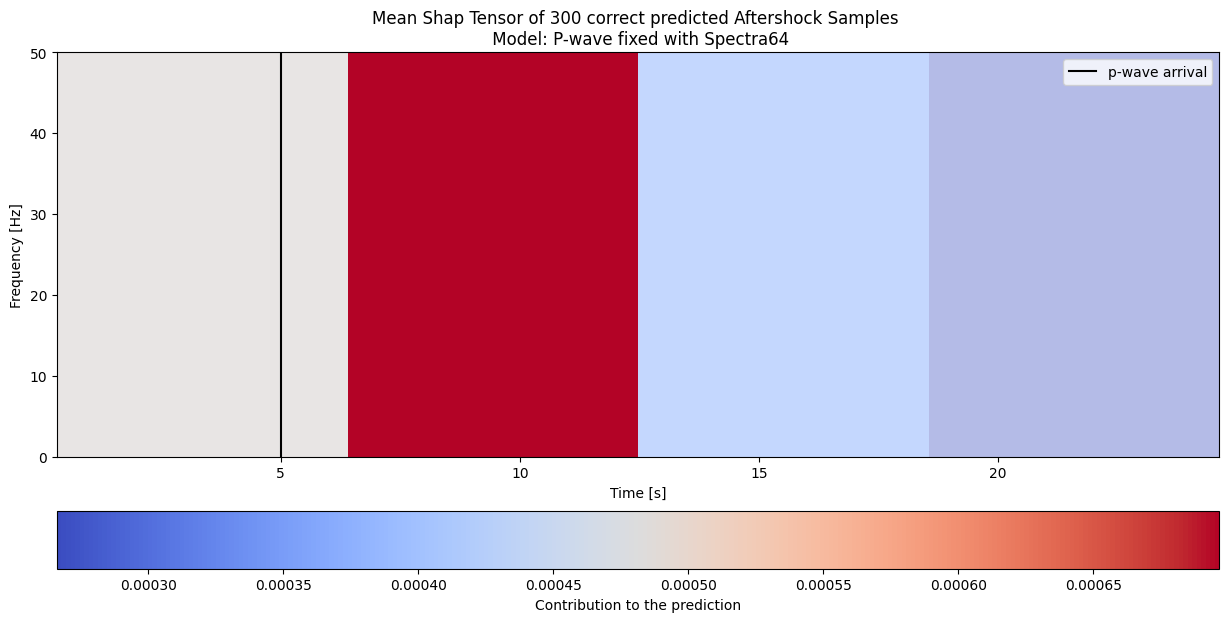

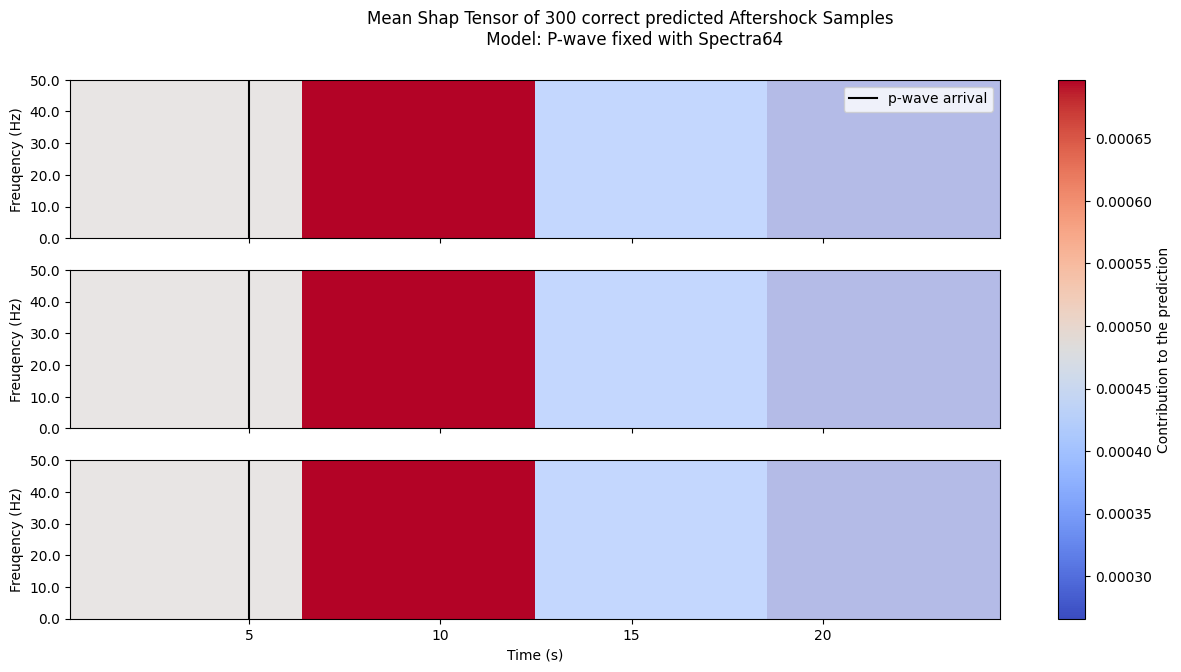

In [14]:
plot_shap(mean_shap_tensor, onechannel=True, background=None, ft = ft, spec_type="p64", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: P-wave fixed with Spectra64")
plot_shap(mean_shap_tensor, onechannel=False, background=None, ft = ft, spec_type="p64", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: P-wave fixed with Spectra64")

### Spectra32 Settings
$
\textbf{NPERSEG} = 32
$

$
\textbf{NOVERLAP} = \textbf{NPERSEG} * 0.5
$

In [15]:
model = CNN2D.load_from_checkpoint(best_model_p_32, input_dim=dim_p32, num_classes=2)
model.eval()
model.to(device)
print("Model loaded")

Model loaded


#### Foreshocks

In [16]:
dset_pre = SpectraDataset_p(os.path.join(data_path_32_p, "foreshock"), transform=transform_32, get_image_name=True)
dloader_pre = DataLoader(dset_pre, batch_size=30, shuffle=False)

In [17]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_pre, dim_p32, device, max_evals = 10, masker_settings = "inpaint_telea", save_path = None)

Computing Mean SHAP Tensor: 100%|██████████| 11/11 [00:16<00:00,  1.53s/it]


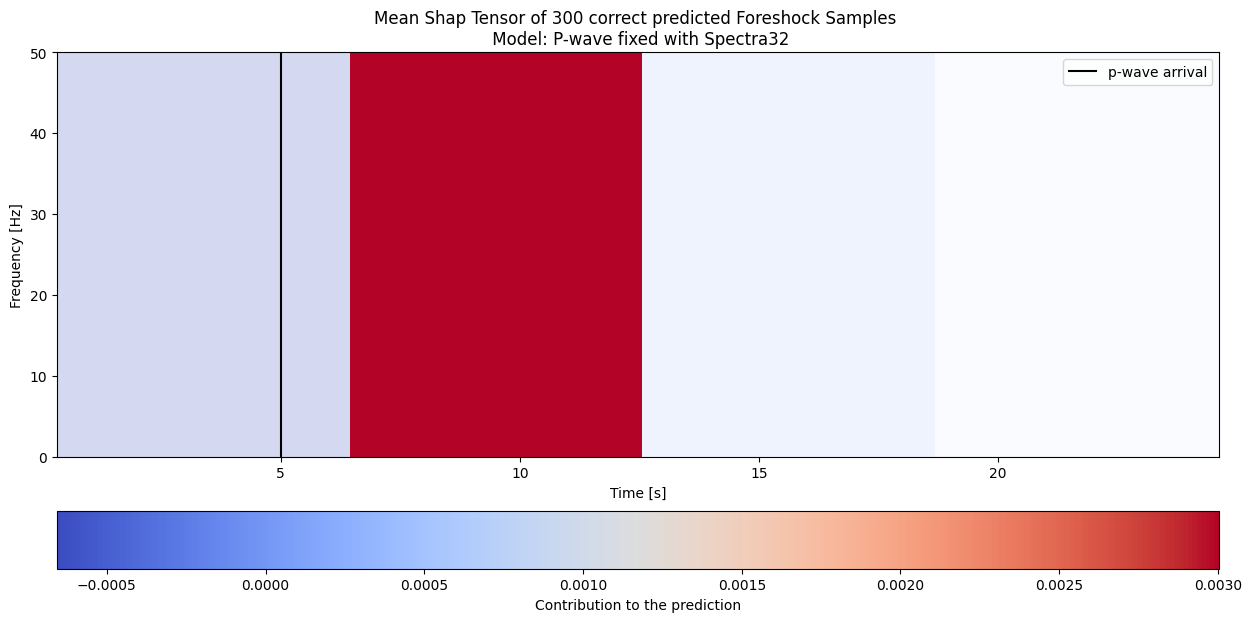

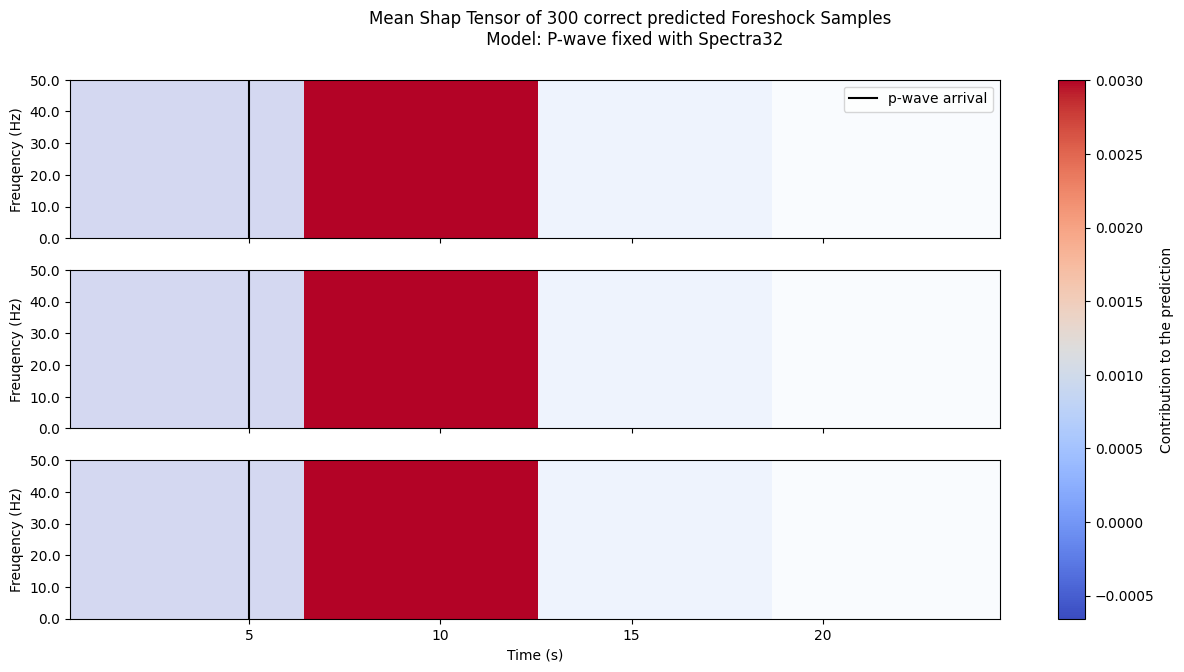

In [18]:
plot_shap(mean_shap_tensor, onechannel=True, background=None, ft = ft, spec_type="p32", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: P-wave fixed with Spectra32")
plot_shap(mean_shap_tensor, onechannel=False, background=None, ft = ft, spec_type="p32", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: P-wave fixed with Spectra32")

#### Aftershocks

In [19]:
dset_post = SpectraDataset_p(os.path.join(data_path_32_p, "aftershock"), transform=transform_32, get_image_name=True)
dloader_post = DataLoader(dset_post, batch_size=30, shuffle=False)

In [20]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_post, dim_p32, device, max_evals = 10, masker_settings = "inpaint_telea", save_path = None)

Computing Mean SHAP Tensor: 100%|██████████| 13/13 [00:19<00:00,  1.53s/it]


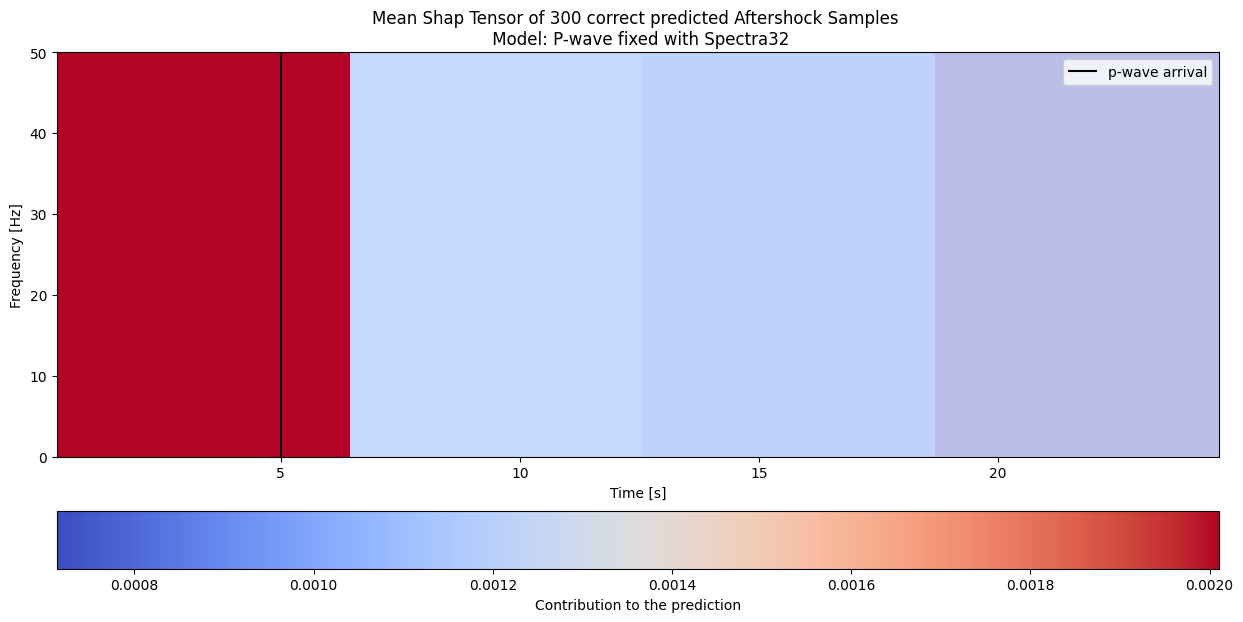

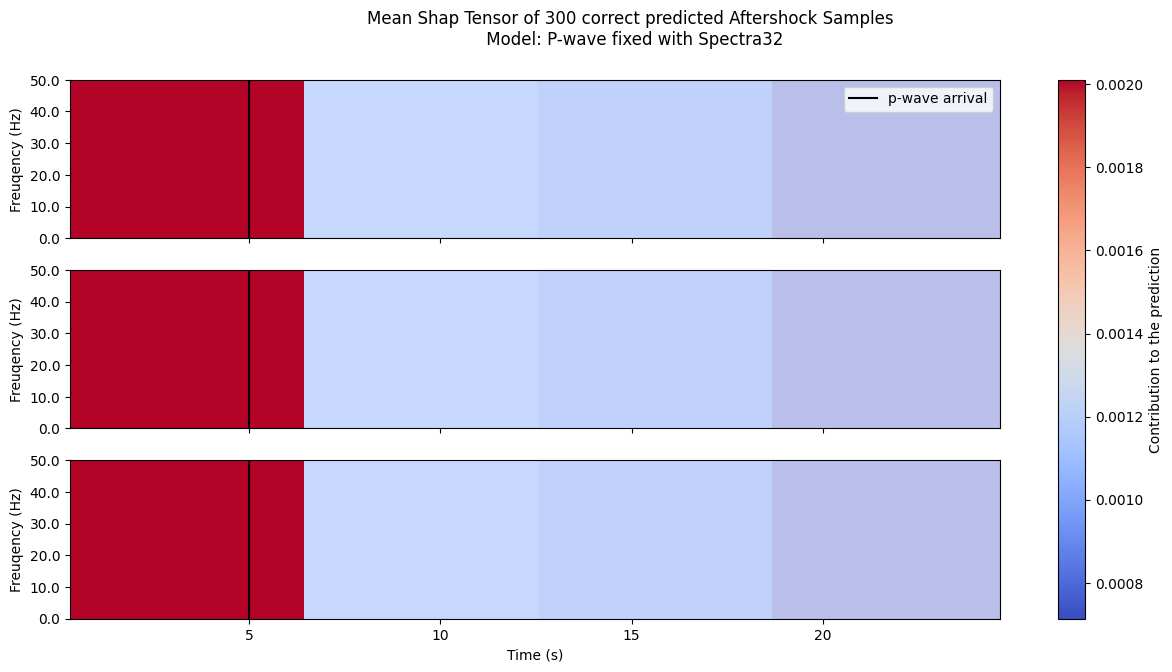

In [21]:
plot_shap(mean_shap_tensor, onechannel=True, background=None, ft = ft, spec_type="p32", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: P-wave fixed with Spectra32")
plot_shap(mean_shap_tensor, onechannel=False, background=None, ft = ft, spec_type="p32", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: P-wave fixed with Spectra32")